In [1]:
setwd('/sc/arion/projects/roussp01a/liting/Olf/figures/downstream_scdrs_goldstein//')
scdrs_outps <-  list.files('./', pattern = 'scdrs_group.N_types_stage')

cor_traits <- c()
for (trait in scdrs_outps){
  cor_trait <- read.table(trait, header = T)
  cor_trait$trait <- trait
  cor_traits <- rbind(cor_traits, cor_trait )
}


mytraits=list(`Psychiatric`=c('sz3','adhd_ipsych',"mdd_ipsych",'asd_ipsych', "bip_koromina_2024"),#,'insomn2'
             # Behavioral=c("drinking", "smoking",'eduAttainment','alcoholism_2019',"intel",'gaming'),
              Neurological=c('alzBellenguez','als2021','ms','pd_without_23andMe','stroke')#,
              #`Non-brain related`=c('bmi','height',"covid19_A1", "covid19_A2", "covid19_B1", "covid19_B2")
)

In [2]:
cor_traits$Trait <- gsub(".scdrs_group.N_types_stage", '', cor_traits$trait)
cor_traits <- subset(cor_traits, Trait%in% unlist(mytraits))

cor_traits$assoc_mcfdr <- p.adjust(cor_traits$assoc_mcp,method = 'fdr')
cor_traits$hetero_mcfdr<- p.adjust(cor_traits$hetero_mcp,method = 'fdr')

In [6]:
cor_traits$plotLabel <- ifelse(cor_traits$assoc_mcfdr < 0.05,'#',ifelse(cor_traits$assoc_mcp < 0.05,'x','')) 
cor_traits$trait <- gsub('.scdrs_group.N_types_stage','',cor_traits$trait)
# cor_traits_sig <- subset(cor_traits, trait%in%subset(cor_traits, assoc_mcp < 0.1)$trait)
# cor_traits_sig$plotLabel2 <- ifelse(cor_traits_sig$assoc_mcp < 0.05 & cor_traits_sig$hetero_mcp < 0.05, 'x','' ) 


mytraits_df <- data.frame()
for (term in names(mytraits)){
  disease <- mytraits[[term]]
  df <- cbind(rep(term, length(disease)),disease)
  mytraits_df <- rbind( mytraits_df,df)
}

rownames(mytraits_df) <- mytraits_df$disease

select_trait <- subset(cor_traits,trait%in%mytraits_df$disease)
select_trait$category <- factor(mytraits_df[select_trait$trait,'V1'], levels = names(mytraits))
  
library(RColorBrewer)
library(ggplot2)
myPalette = colorRampPalette(brewer.pal(9, 'RdYlBu'), space="Lab")
library(stringr)
select_trait$Traits <- gsub('\\d','',str_split(select_trait$trait,'_',simplify = T)[,1])
select_trait$Traits <- str_to_title(select_trait$Traits)
select_trait$Traits[select_trait$Traits=='Alzbellenguez'] <- 'AD'
select_trait$Traits[select_trait$Traits=='Sz'] <- 'SCZ'

pdf 
  2

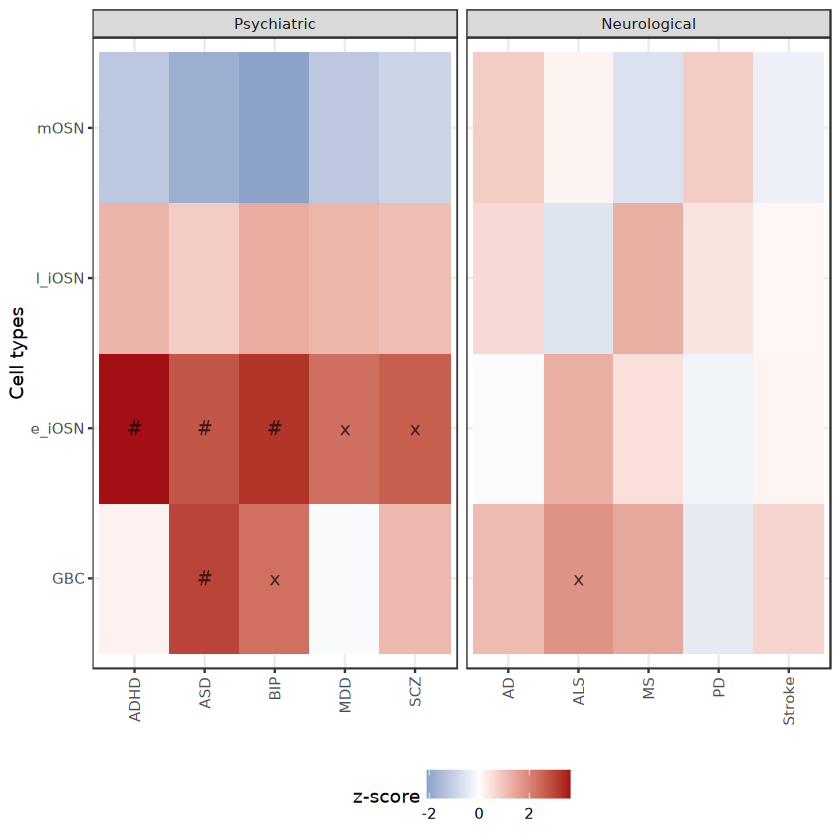

In [8]:
select_trait$Traits <- ifelse(select_trait$Traits%in%str_to_title(c('adhd','asd','bip','mdd','scz','als','ms','pd')),toupper(select_trait$Traits),select_trait$Traits)
ggplot(select_trait, aes(x= Traits, y= factor(group, levels = c("GBC",    "e_iOSN", "l_iOSN" ,"mOSN"  ))))+
#ggplot(subset(cor_traits_sig), aes(x=trait, y=group))+  
  geom_tile(aes(fill=assoc_mcz)) + 
  #scale_fill_distiller(palette = "RdBu")+
  scale_fill_gradient2(low='#2765A2',high='#A40F14')+
  geom_text(aes(label=plotLabel),alpha=0.7)+
  theme_bw()+ylab('Cell types')+
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),legend.position ='bottom',
        #plot.caption = element_text(hjust = 1,vjust = 1)
        )+ facet_grid(~category,scales = 'free_x',space='free')+
  ylab('Cell types')+xlab('')+labs(fill='z-score') #caption = "*: p < 0.05",
dev.print(pdf, file='/sc/arion/projects/roussp01a/liting/Olf/figures/scdrs_bycelltypestage_fdr_goldstein.pdf', width=5, height=4)

In [10]:
write.table(select_trait[,c('group', 'category', 'Traits', 'assoc_mcz', 'assoc_mcp','assoc_mcfdr'  )], file='/sc/arion/projects/roussp01a/liting/Olf/data/NC/f1i.txt', sep='\t', quote = F)

In [19]:
#dev.print(pdf, file='/sc/arion/projects/roussp01a/liting/Olf/figures/scdrs_bycelltypestage.pdf', width=6, height=4.5)
dev.print(pdf, file='/sc/arion/projects/roussp01a/liting/Olf/figures/scdrs_bycelltypestage_fdr.pdf', width=5, height=4)


gene_score <- read.table('/sc/arion/projects/roussp01a/liting/Olf/figures/scdrs_Full_score/alcoholism_2019.score.gz')

ent_NN <- readRDS(paste0('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/','ent_nn_merge','.rds'))

data <- ent_NN
#data <- subset(data,batch%in%c(setdiff(unique(data$batch),c('Set4_C1','Set4_C2','Set1_C1','Set2_C1','Set2_C2') )))

#data[["RNA"]] <- split(data[["RNA"]], f = data$batch)

data <- NormalizeData(data)
data <- FindVariableFeatures(data,selection.method='mean.var.plot')
data <- ScaleData(data,features=VariableFeatures(data))
#run PCA. Select significant PCs based on a scree plot. Look for the last point before the plot becomes flat
data <- RunPCA(data,features = VariableFeatures(data),verbose=F)
data<- FindNeighbors(data, reduction = "pca", dims = 1:10) %>% FindClusters(resolution = 0.1)

# 3. clusters before batch correction
data <- RunUMAP(data, dims = 1:10, reduction = "pca", reduction.name = "umap.unintegrated")
DimPlot(data, reduction = "umap.unintegrated", group.by = c("batch", "N_types"))

# 4. batch correction
## 4.1 cca
obj <- IntegrateLayers(
  object = data, method = CCAIntegration,k.weight=10,
  orig.reduction = "pca", new.reduction = "integrated.cca",
  verbose = FALSE,dims = 1:8
)


# 5 identify cell clusters
## 5.1 cca
obj <- FindNeighbors(obj, reduction = "integrated.cca", dims = 1:8)
obj <- FindClusters(obj, resolution = 0.5, cluster.name = "cca_clusters")
obj <- RunUMAP(obj, reduction = "integrated.cca", dims = 1:8, reduction.name = "umap.cca")

obj$gene_score <- gene_score[colnames(obj),'norm_score']

DimPlot(
  obj,
  reduction = "umap.cca",
  group.by = c("batch" ,'dataset','N_types'),label.size = 2
)

FeaturePlot(obj, features = "gene_score",  reduction = "umap.cca" )

pdf 
  2

ERROR: Error in NormalizeData(data): could not find function "NormalizeData"
